# NB03 — Multivariable Model, Out-of-Study Test & Variance Partitioning

The univariate association (NB02) is confounded: matrix ≈ study. Here we ask the honest questions:
1. **H1a (adjusted):** does environment predict euk fraction *across held-out studies* (GroupKFold by `study_id`)?
2. **Batch share:** how much variance does `study_id` alone explain vs environment alone?
3. **H1c:** does adding sequencing (platform, depth) improve prediction beyond environment?

Model: HistGradientBoosting (regressor for `euk_logit`, classifier for `euk_detect`). Honest generalisation
via `GroupKFold(groups=study_id)` so no study is split across train/test.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
DATA=Path('../data'); FIG=Path('../figures')
plt.rcParams.update({'figure.dpi':110,'savefig.bbox':'tight','axes.grid':True,'grid.alpha':.3})
df = pd.read_csv(DATA/'analysis_clean.csv')
df['study_id']=df['study_id'].fillna('NA')
print(len(df),'samples,',df.study_id.nunique(),'studies')

5871 samples, 16 studies


## Feature construction (capped cardinality, one-hot)

In [2]:
def cap(s, k, other='Other'):
    top=s.value_counts().head(k).index
    return s.where(s.isin(top), other)
X = pd.DataFrame(index=df.index)
env_cols = {}
for name,series,k in [('eco',df['ecosystem_type'],8),('env',df['env_medium'],15),
                      ('dev',df['samp_collec_device'].fillna('Unknown'),10)]:
    d=pd.get_dummies(cap(series.fillna('Unknown'),k),prefix=name)
    env_cols[name]=list(d.columns); X=pd.concat([X,d],axis=1)
seq_cols=[]
dp=pd.get_dummies(cap(df['platform'].fillna('Unknown'),6),prefix='plat'); seq_cols+=list(dp.columns)
X=pd.concat([X,dp],axis=1)
X['log_depth']=df['log_depth'].fillna(0); seq_cols.append('log_depth')
ENV=[c for cols in env_cols.values() for c in cols]
SEQ=seq_cols
y=df['euk_logit'].values; yb=df['euk_detect'].values; groups=df['study_id'].values
print(f'features: {len(ENV)} environment + {len(SEQ)} sequencing = {X.shape[1]} total')

features: 33 environment + 7 sequencing = 40 total


## Honest generalisation: GroupKFold (hold out whole studies) vs random KFold

In [3]:
gkf=GroupKFold(n_splits=5)
def r2_cv(cols, cv, grp=None):
    m=HistGradientBoostingRegressor(max_depth=4,learning_rate=.08,max_iter=300,random_state=0)
    if grp is not None:
        return cross_val_score(m,X[cols],y,cv=cv,groups=grp,scoring='r2')
    return cross_val_score(m,X[cols],y,cv=cv,scoring='r2')
res={}
res['study_only_group']=r2_cv(None if False else ENV,gkf,groups)  # placeholder replaced below
# study-only model: one-hot of study cannot be tested out-of-study (leakage), so report IN-sample only as batch ceiling
studyX=pd.get_dummies(df['study_id'],prefix='study')
m=HistGradientBoostingRegressor(max_depth=4,learning_rate=.08,max_iter=300,random_state=0)
from sklearn.model_selection import cross_val_score as cvs, KFold
study_r2=cvs(m,studyX,y,cv=KFold(5,shuffle=True,random_state=0),scoring='r2').mean()
env_rand=r2_cv(ENV,KFold(5,shuffle=True,random_state=0)).mean()
env_group=r2_cv(ENV,gkf,groups).mean()
full_rand=r2_cv(ENV+SEQ,KFold(5,shuffle=True,random_state=0)).mean()
full_group=r2_cv(ENV+SEQ,gkf,groups).mean()
part=pd.Series({'study_id only (random CV, batch ceiling)':study_r2,
               'environment (random CV)':env_rand,
               'environment (GroupKFold, out-of-study)':env_group,
               'environment+sequencing (random CV)':full_rand,
               'environment+sequencing (GroupKFold)':full_group}).round(3)
print('R^2 (euk_logit):'); print(part.to_string())
part.to_csv(DATA/'variance_partition.csv')

R^2 (euk_logit):
study_id only (random CV, batch ceiling)    0.247
environment (random CV)                     0.266
environment (GroupKFold, out-of-study)     -0.212
environment+sequencing (random CV)          0.268
environment+sequencing (GroupKFold)        -0.345


## Detection classifier (euk>0): out-of-study AUC

In [4]:
def auc_group(cols):
    aucs=[]
    for tr,te in gkf.split(X,yb,groups):
        if len(np.unique(yb[te]))<2: continue
        c=HistGradientBoostingClassifier(max_depth=4,learning_rate=.08,max_iter=300,random_state=0)
        c.fit(X[cols].iloc[tr],yb[tr]); p=c.predict_proba(X[cols].iloc[te])[:,1]
        aucs.append(roc_auc_score(yb[te],p))
    return np.mean(aucs),np.std(aucs)
for label,cols in [('environment',ENV),('environment+sequencing',ENV+SEQ)]:
    mu,sd=auc_group(cols); print(f'{label:24s} out-of-study AUC = {mu:.3f} ± {sd:.3f}')

environment              out-of-study AUC = 0.712 ± 0.231


environment+sequencing   out-of-study AUC = 0.685 ± 0.240


## Permutation importance (full model, out-of-study fold)

In [5]:
tr,te=next(gkf.split(X,y,groups))
m=HistGradientBoostingRegressor(max_depth=4,learning_rate=.08,max_iter=300,random_state=0).fit(X[ENV+SEQ].iloc[tr],y[tr])
pi=permutation_importance(m,X[ENV+SEQ].iloc[te],y[te],n_repeats=10,random_state=0)
imp=pd.Series(pi.importances_mean,index=ENV+SEQ).sort_values(ascending=False)
# group by predictor family
fam=imp.copy(); fam.index=[i.split('_')[0] for i in imp.index]
famsum=fam.groupby(level=0).sum().sort_values(ascending=False)
print('Permutation importance by predictor family (drop in R^2):')
print(famsum.round(4).to_string())
famsum.to_csv(DATA/'permutation_importance_family.csv')

Permutation importance by predictor family (drop in R^2):
env     0.0097
plat    0.0000
log     0.0000
eco    -0.0024
dev    -0.0290


## Figure 3 — Variance partition & importance

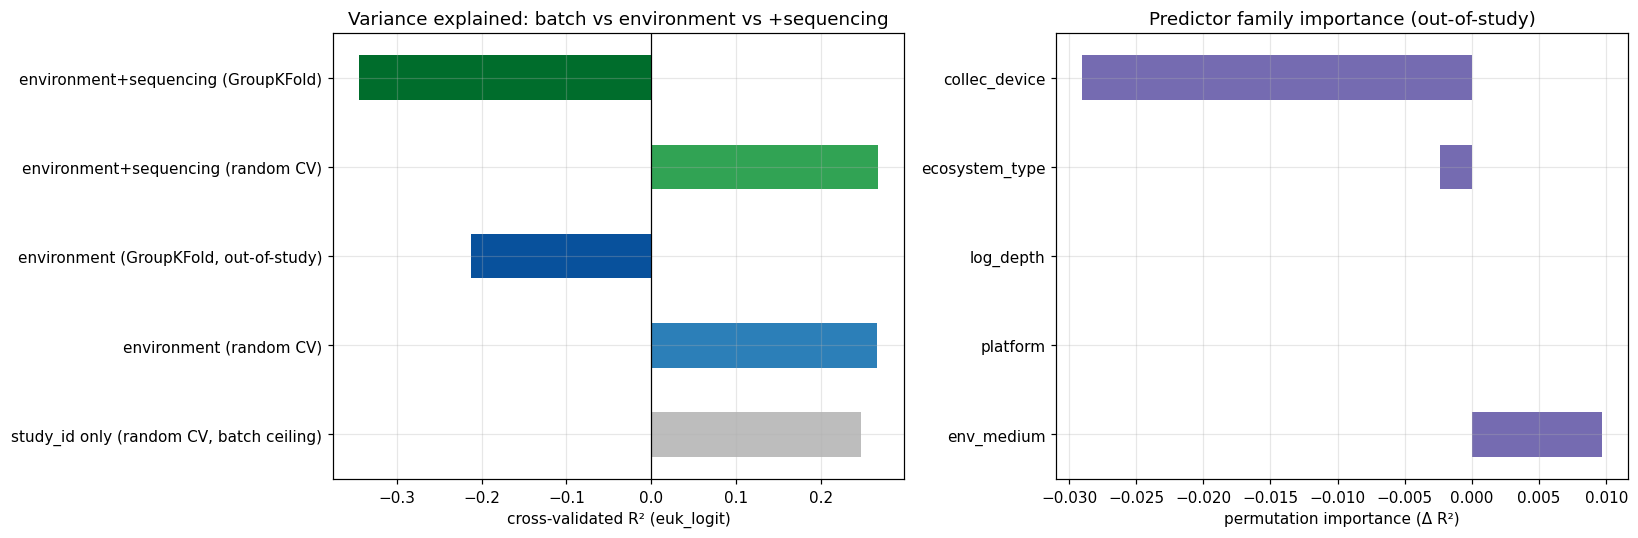

saved fig03


In [6]:
fig,axes=plt.subplots(1,2,figsize=(15,5))
ax=axes[0]
colors=['#bdbdbd','#2c7fb8','#08519c','#31a354','#006d2c']
part.plot.barh(ax=ax,color=colors); ax.set_xlabel('cross-validated R² (euk_logit)')
ax.set_title('Variance explained: batch vs environment vs +sequencing')
ax.axvline(0,color='k',lw=.8)
ax=axes[1]
fam_names={'eco':'ecosystem_type','env':'env_medium','dev':'collec_device','plat':'platform','log':'log_depth'}
famsum.rename(index=fam_names).plot.barh(ax=ax,color='#756bb1')
ax.set_xlabel('permutation importance (Δ R²)'); ax.set_title('Predictor family importance (out-of-study)')
plt.tight_layout(); plt.savefig(FIG/'fig03_variance_partition.png'); plt.show()
print('saved fig03')

## NB03 takeaways (interpretation written in REPORT via /synthesize)
- Compare **environment random-CV R²** vs **environment GroupKFold R²**: the gap quantifies how much the
  apparent environment effect is study/batch-specific (does not transfer to unseen studies).
- **study_id-only R²** is the batch ceiling.
- **H1c:** if environment+sequencing ≈ environment (both CV schemes), sequencing adds little beyond matrix.
- Permutation importance ranks which metadata families carry the transferable signal.